# Test dei modelli FPViT a 224 px

Valuta i modelli in `trained_models_224/` sui test set di riferimento, **mai usati durante il training né per scegliere il checkpoint**:

| test set | immagini | cosa misura |
| --- | --- | --- |
| **DermaMNIST-C test** | 1227 | stessa distribuzione del training (HAM10000), lesioni mai viste |
| **DermaMNIST-E test** | 1511 | test ISIC 2018: **esterno**, lesioni e condizioni di acquisizione diverse |

Per ogni modello, e per l'**ensemble** dei seed (media delle probabilità), calcola accuracy, balanced accuracy, macro-F1 e macro-AUC, le metriche per classe e la **matrice di confusione**. Come riferimento valuta anche `baseline_paper` (FPViT a 28 px sullo split ufficiale) sugli stessi test: le lesioni di questi test non sono nel suo train, quindi il confronto è pulito.

**Da ricordare:** guardare il test e poi cambiare configurazione o scegliere il modello in base a questi numeri lo trasforma in una seconda validation. Le scelte si fanno sulla validation (cella 8 del notebook Colab); qui si misura soltanto.

Si esegue dalla cartella `notebooks/` con il `.venv` del progetto. Al primo avvio scarica da Zenodo i test set in `~/.medmnist`, con verifica MD5: circa 2,4 GB a 224 px e 45 MB a 28 px. Se li hai già scaricati altrove, imposta `DATA_ROOT`.

## 1 — Setup

In [1]:
import json, sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix,
                             f1_score, precision_recall_fscore_support, roc_auc_score)

PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT))
from fpvit.dataset import dataset_file, eval_transform_for, load_split, model_input
from fpvit.engine import resolve_device
from fpvit.zoo import build_from_config

MODELS_DIR = PROJECT / "trained_models_224"
BASELINE   = PROJECT / "runs test solo training pyramid" / "baseline_paper" / "best_model.pt"
OUT_DIR    = MODELS_DIR / "test_results"
DATA_ROOT  = None                    # None = ~/.medmnist
TEST_SETS  = ["dermamnist_c", "dermamnist_e"]
INCLUDE_BASELINE = True
BATCH_SIZE = 64

device = resolve_device("auto")
OUT_DIR.mkdir(exist_ok=True)
CLASSES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CLASS_NAMES = ["actinic keratoses / intraep. carcinoma", "basal cell carcinoma",
               "benign keratosis-like", "dermatofibroma", "melanoma",
               "melanocytic nevi", "vascular lesions"]
print("progetto:", PROJECT, "| device:", device)

progetto: /Users/emanuele/Desktop/dermaAgent training/pyramid_project | device: mps


## 2 — I modelli e cosa dice la validation

In [2]:
def load_model(path):
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    model = build_from_config(ckpt["config"]).to(device).eval()
    model.load_state_dict(ckpt["model_state_dict"])
    return model, ckpt

models, rows = {}, []
for path in sorted(MODELS_DIR.glob("*/best_model.pt")):
    name = path.parent.name
    model, ckpt = load_model(path)
    cfg, vm = ckpt["config"], ckpt["val_metrics"]
    rec = json.loads((path.parent / "experiment_record.json").read_text())
    models[name] = {"model": model, "cfg": cfg}
    rows.append({"modello": name, "dataset": cfg.get("dataset"), "input": f"{model_input(cfg)[0]} px",
                 "pretrained": cfg.get("pretrained"), "seed": cfg.get("seed"),
                 "stop": rec["stop_reason"], "epoche": rec["epochs_completed"], "epoca scelta": ckpt["epoch"],
                 "val bal_acc": vm["balanced_acc"], "val macro_auc": vm["macro_auc"], "val acc": vm["acc"]})
    assert cfg.get("dataset") == "dermamnist_c", f"{name}: addestrato su {cfg.get('dataset')}, non su C"

if INCLUDE_BASELINE and BASELINE.exists():
    model, ckpt = load_model(BASELINE)
    models["baseline_paper_28"] = {"model": model, "cfg": ckpt["config"]}
    rows.append({"modello": "baseline_paper_28", "dataset": "dermamnist (ufficiale)", "input": "28 px",
                 "pretrained": False, "seed": ckpt["config"].get("seed"), "epoca scelta": ckpt["epoch"],
                 "val bal_acc": ckpt["val_metrics"]["balanced_acc"],
                 "val macro_auc": ckpt["val_metrics"]["macro_auc"], "val acc": ckpt["val_metrics"]["acc"]})

display(pd.DataFrame(rows).round(3))
print("Nota: la validation di baseline_paper e' quella ufficiale (con leakage), non C-val: i numeri 'val' non sono confrontabili tra le righe.")

/Users/emanuele/Desktop/dermaAgent training/pyramid_project/fpvit/model.py:167: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  return nn.TransformerEncoder(layer, num_layers=depth)


,modello,dataset,input,pretrained,seed,stop,epoche,epoca scelta,val bal_acc,val macro_auc,val acc
0,fpvit_c224_pretrained_s42,dermamnist_c,224 px,True,42,early_stop,21.0,6,0.756,0.985,0.902
1,fpvit_c224_pretrained_s43,dermamnist_c,224 px,True,43,early_stop,31.0,16,0.754,0.981,0.906
2,baseline_paper_28,dermamnist (ufficiale),28 px,False,42,NaN,NaN,34,0.533,0.925,0.737


Nota: la validation di baseline_paper e' quella ufficiale (con leakage), non C-val: i numeri 'val' non sono confrontabili tra le righe.


## 3 — Previsioni sui test set

Ogni modello riceve le immagini alla **sua** risoluzione e con la **sua** normalizzazione, entrambe lette dal checkpoint: 224 px con statistiche ImageNet per i modelli pre-addestrati, 28 px per `baseline_paper`. L'**ensemble** è la media delle probabilità dei modelli a 224 px, tutti con lo stesso peso.

In [3]:
@torch.no_grad()
def predict_probs(model, cfg, dataset):
    img_size, _ = model_input(cfg)
    ds = load_split("test", eval_transform_for(cfg), dataset, img_size, DATA_ROOT)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    probs = [torch.softmax(model(x.to(device)), 1).cpu() for x, _ in loader]
    return torch.cat(probs).numpy(), ds.labels.reshape(-1).astype(int)

PROBS, LABELS = {}, {}
for ds_name in TEST_SETS:
    PROBS[ds_name] = {}
    for name, m in models.items():
        p, y = predict_probs(m["model"], m["cfg"], ds_name)
        PROBS[ds_name][name] = p
        if ds_name in LABELS:
            assert (LABELS[ds_name] == y).all(), "etichette diverse tra risoluzioni: stesso ordine atteso"
        LABELS[ds_name] = y
        print(f"{ds_name:13s} {name:28s} {len(y)} immagini")
    members = [n for n in PROBS[ds_name] if n != "baseline_paper_28"]
    if len(members) > 1:
        PROBS[ds_name]["ensemble_224"] = np.mean([PROBS[ds_name][n] for n in members], axis=0)

for ds_name, y in LABELS.items():
    print(f"\n{ds_name}: immagini per classe", dict(zip(CLASSES, np.bincount(y, minlength=7).tolist())))

dermamnist_corrected_224.npz: 100%|██████████| 1.13G/1.13G [03:38<00:00, 5.18MB/s]


dermamnist_c  fpvit_c224_pretrained_s42    1227 immagini
dermamnist_c  fpvit_c224_pretrained_s43    1227 immagini


dermamnist_corrected_28.npz: 100%|██████████| 20.7M/20.7M [00:09<00:00, 2.20MB/s]


dermamnist_c  baseline_paper_28            1227 immagini


dermamnist_extended_224.npz: 100%|██████████| 1.33G/1.33G [04:13<00:00, 5.23MB/s]


dermamnist_e  fpvit_c224_pretrained_s42    1511 immagini
dermamnist_e  fpvit_c224_pretrained_s43    1511 immagini


dermamnist_extended_28.npz: 100%|██████████| 24.6M/24.6M [00:07<00:00, 3.20MB/s]


dermamnist_e  baseline_paper_28            1511 immagini

dermamnist_c: immagini per classe {'akiec': 35, 'bcc': 44, 'bkl': 105, 'df': 8, 'mel': 70, 'nv': 948, 'vasc': 17}

dermamnist_e: immagini per classe {'akiec': 43, 'bcc': 93, 'bkl': 217, 'df': 44, 'mel': 171, 'nv': 908, 'vasc': 35}


## 4 — Metriche aggregate

In [4]:
def metrics(y, p):
    pred = p.argmax(1)
    try:
        auc = roc_auc_score(y, p, multi_class="ovr", average="macro", labels=list(range(7)))
    except ValueError:
        auc = np.nan
    return {"accuracy": accuracy_score(y, pred), "balanced_acc": balanced_accuracy_score(y, pred),
            "macro_f1": f1_score(y, pred, average="macro", zero_division=0), "macro_auc": auc}

summary = pd.DataFrame([{"test": ds, "modello": name, **metrics(LABELS[ds], p)}
                        for ds in PROBS for name, p in PROBS[ds].items()])
display(summary.set_index(["test", "modello"]).round(3))
summary.to_csv(OUT_DIR / "summary.csv", index=False)

accuracy  balanced_acc  macro_f1  \
test         modello                                                       
dermamnist_c fpvit_c224_pretrained_s42     0.891         0.779     0.686   
             fpvit_c224_pretrained_s43     0.892         0.779     0.720   
             baseline_paper_28             0.770         0.537     0.451   
             ensemble_224                  0.901         0.782     0.717   
dermamnist_e fpvit_c224_pretrained_s42     0.784         0.678     0.663   
             fpvit_c224_pretrained_s43     0.782         0.657     0.669   
             baseline_paper_28             0.609         0.462     0.408   
             ensemble_224                  0.802         0.692     0.691   

                                        macro_auc  
test         modello                               
dermamnist_c fpvit_c224_pretrained_s42      0.982  
             fpvit_c224_pretrained_s43      0.982  
             baseline_paper_28              0.948  
             ensemble_224                   0.985  
dermamnist_e fpvit_c224_pretrained_s42      0.956  
             fpvit_c224_pretrained_s43      0.953  
             baseline_paper_28              0.881  
             ensemble_224                   0.961

## 5 — Metriche per classe

Con classi così sbilanciate (i nevi sono circa due terzi) l'accuracy da sola inganna: la recall per classe dice se le classi rare vengono riconosciute davvero. Il *support* è il numero di immagini della classe nel test.

In [5]:
per_class = []
for ds in PROBS:
    y = LABELS[ds]
    for name, p in PROBS[ds].items():
        prec, rec, f1, sup = precision_recall_fscore_support(y, p.argmax(1), labels=list(range(7)), zero_division=0)
        for c in range(7):
            onehot = (y == c).astype(int)
            auc_c = roc_auc_score(onehot, p[:, c]) if 0 < onehot.sum() < len(y) else np.nan
            per_class.append({"test": ds, "modello": name, "classe": CLASSES[c], "precision": prec[c],
                              "recall": rec[c], "f1": f1[c], "auc": auc_c, "support": int(sup[c])})
per_class = pd.DataFrame(per_class)
per_class.to_csv(OUT_DIR / "per_class.csv", index=False)

for ds in PROBS:
    print(f"\n=== {ds} — recall per classe ===")
    display(per_class[per_class.test == ds].pivot(index="modello", columns="classe", values="recall")[CLASSES].round(3))


=== dermamnist_c — recall per classe ===


classe,akiec,bcc,bkl,df,mel,nv,vasc
modello,,,,,,,
baseline_paper_28,0.371,0.545,0.429,0.0,0.686,0.844,0.882
ensemble_224,0.371,0.750,0.790,1.0,0.729,0.953,0.882
fpvit_c224_pretrained_s42,0.400,0.886,0.686,1.0,0.714,0.945,0.824
fpvit_c224_pretrained_s43,0.400,0.705,0.800,1.0,0.729,0.941,0.882



=== dermamnist_e — recall per classe ===


classe,akiec,bcc,bkl,df,mel,nv,vasc
modello,,,,,,,
baseline_paper_28,0.395,0.505,0.346,0.000,0.713,0.704,0.571
ensemble_224,0.512,0.624,0.728,0.886,0.602,0.893,0.600
fpvit_c224_pretrained_s42,0.465,0.688,0.700,0.909,0.538,0.877,0.571
fpvit_c224_pretrained_s43,0.465,0.527,0.751,0.818,0.661,0.861,0.514


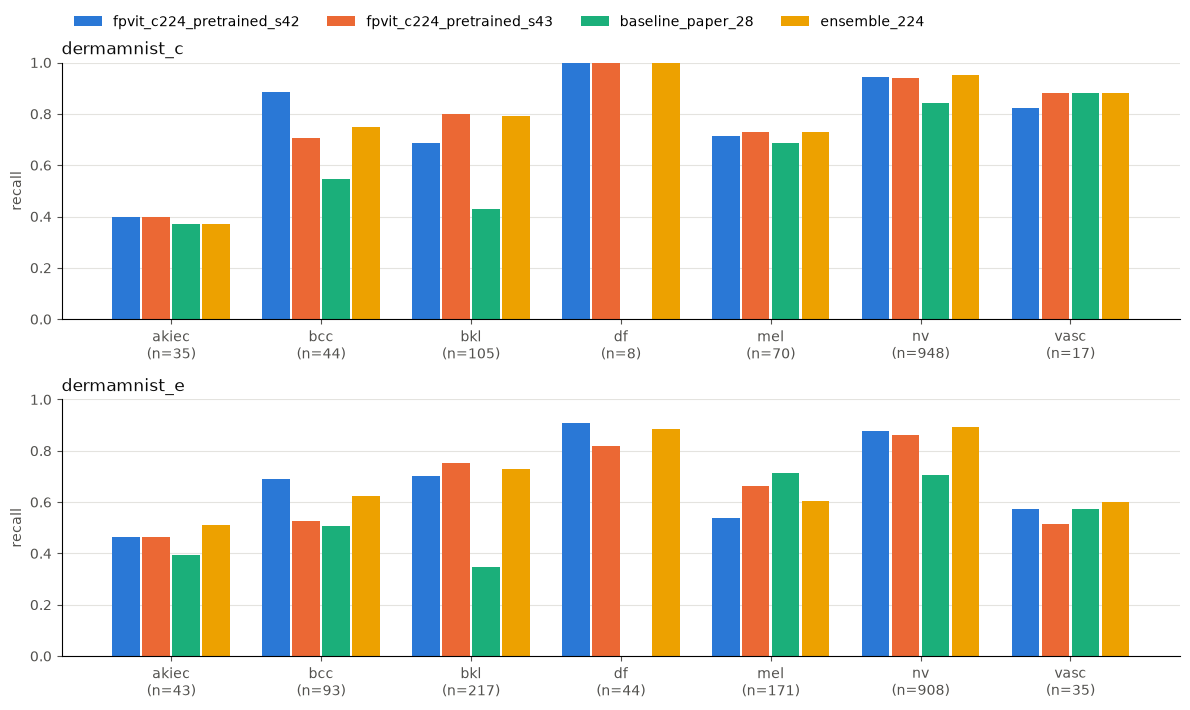

In [6]:
# Recall per classe: un gruppo di barre per classe, una barra per modello.
# Colori categoriali in ordine fisso; il colore segue il modello in tutti i grafici.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
names = list(PROBS[TEST_SETS[0]])
color = {n: SERIES[i % len(SERIES)] for i, n in enumerate(names)}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"

fig, axes = plt.subplots(len(PROBS), 1, figsize=(12, 3.6 * len(PROBS)), sharey=True)
axes = np.atleast_1d(axes)
width = 0.8 / len(names)
for ax, ds in zip(axes, PROBS):
    sub = per_class[per_class.test == ds]
    for i, n in enumerate(names):
        vals = sub[sub.modello == n].set_index("classe").loc[CLASSES, "recall"].values
        x = np.arange(7) + (i - (len(names) - 1) / 2) * width
        ax.bar(x, vals, width * 0.92, color=color[n], label=n, zorder=2)
    sup = sub.drop_duplicates("classe").set_index("classe").loc[CLASSES, "support"]
    ax.set_xticks(np.arange(7), [f"{c}\n(n={s})" for c, s in zip(CLASSES, sup)], color=INK2)
    ax.set_ylim(0, 1); ax.set_ylabel("recall", color=INK2); ax.set_title(ds, loc="left", color=INK)
    ax.grid(axis="y", color=GRID, zorder=0); ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(colors=INK2)
axes[0].legend(ncol=len(names), frameon=False, loc="lower left", bbox_to_anchor=(0, 1.08))
plt.tight_layout(); plt.savefig(OUT_DIR / "recall_per_class.png", dpi=150); plt.show()

## 6 — Matrici di confusione

Righe = classe vera, colonne = classe predetta. Il colore e la percentuale sono **normalizzati per riga**: la diagonale è la recall di ogni classe, e fuori diagonale si legge dove finiscono gli errori. Il numero tra parentesi è il conteggio di immagini. Una matrice per test set e per modello: `MATRIX_MODELS` sceglie quali mostrare.

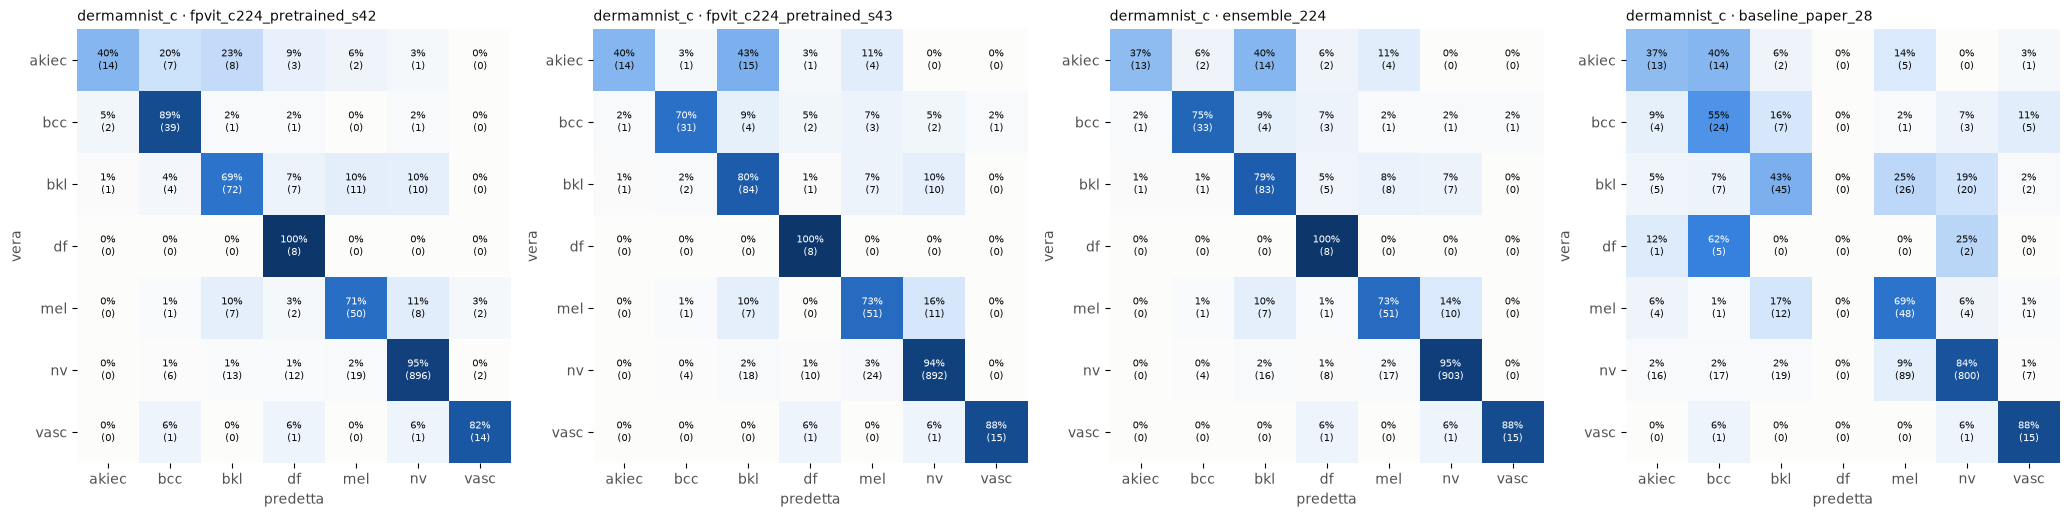

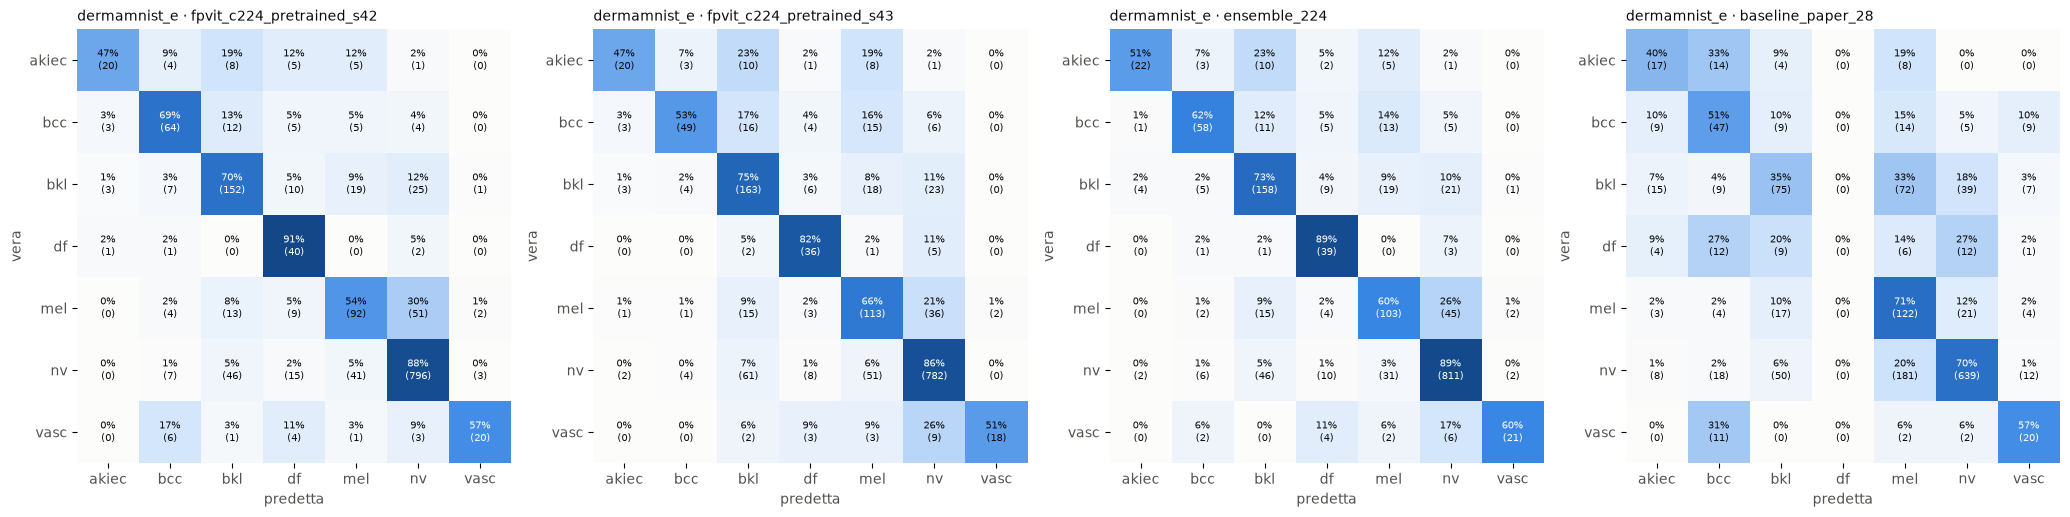

In [7]:
from matplotlib.colors import LinearSegmentedColormap
BLUES = LinearSegmentedColormap.from_list("seq_blue", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
MATRIX_MODELS = [n for n in names if n != "baseline_paper_28"] + (["baseline_paper_28"] if "baseline_paper_28" in names else [])

def plot_confusion(ax, y, pred, title):
    cm = confusion_matrix(y, pred, labels=list(range(7)))
    norm = cm / np.maximum(cm.sum(1, keepdims=True), 1)
    ax.imshow(norm, cmap=BLUES, vmin=0, vmax=1)
    for i in range(7):
        for j in range(7):
            ink = "white" if norm[i, j] > 0.55 else INK
            ax.text(j, i, f"{norm[i, j]:.0%}\n({cm[i, j]})", ha="center", va="center", fontsize=7.5, color=ink)
    ax.set_xticks(range(7), CLASSES, color=INK2); ax.set_yticks(range(7), CLASSES, color=INK2)
    ax.set_xlabel("predetta", color=INK2); ax.set_ylabel("vera", color=INK2)
    ax.set_title(title, loc="left", fontsize=10, color=INK)
    for s in ax.spines.values(): s.set_visible(False)
    return cm

CONF = {}
for ds in PROBS:
    k = len(MATRIX_MODELS)
    fig, axes = plt.subplots(1, k, figsize=(5.2 * k, 5))
    for ax, n in zip(np.atleast_1d(axes), MATRIX_MODELS):
        CONF[(ds, n)] = plot_confusion(ax, LABELS[ds], PROBS[ds][n].argmax(1), f"{ds} · {n}")
    plt.tight_layout(); plt.savefig(OUT_DIR / f"confusion_{ds}.png", dpi=150); plt.show()

## 7 — Gli errori più importanti

Due confusioni contano più delle altre in dermatologia:
- un **melanoma predetto come nevo**: un tumore maligno scambiato per benigno;
- un **nevo predetto come melanoma**: un falso allarme, meno grave ma frequente.

Per ogni test set, conteggio delle due confusioni e le immagini sbagliate con la confidenza più alta, per il modello scelto in `SHOW_MODEL`.

In [8]:
MEL, NV = CLASSES.index("mel"), CLASSES.index("nv")
rows = []
for (ds, n), cm in CONF.items():
    rows.append({"test": ds, "modello": n, "melanomi": int(cm[MEL].sum()),
                 "mel -> nv": int(cm[MEL, NV]), "mel -> nv %": cm[MEL, NV] / max(cm[MEL].sum(), 1),
                 "nevi": int(cm[NV].sum()), "nv -> mel": int(cm[NV, MEL]),
                 "nv -> mel %": cm[NV, MEL] / max(cm[NV].sum(), 1)})
display(pd.DataFrame(rows).round(3))

,test,modello,melanomi,mel -> nv,mel -> nv %,nevi,nv -> mel,nv -> mel %
0,dermamnist_c,fpvit_c224_pretrained_s42,70,8,0.114,948,19,0.020
1,dermamnist_c,fpvit_c224_pretrained_s43,70,11,0.157,948,24,0.025
2,dermamnist_c,ensemble_224,70,10,0.143,948,17,0.018
3,dermamnist_c,baseline_paper_28,70,4,0.057,948,89,0.094
4,dermamnist_e,fpvit_c224_pretrained_s42,171,51,0.298,908,41,0.045
5,dermamnist_e,fpvit_c224_pretrained_s43,171,36,0.211,908,51,0.056
6,dermamnist_e,ensemble_224,171,45,0.263,908,31,0.034
7,dermamnist_e,baseline_paper_28,171,21,0.123,908,181,0.199


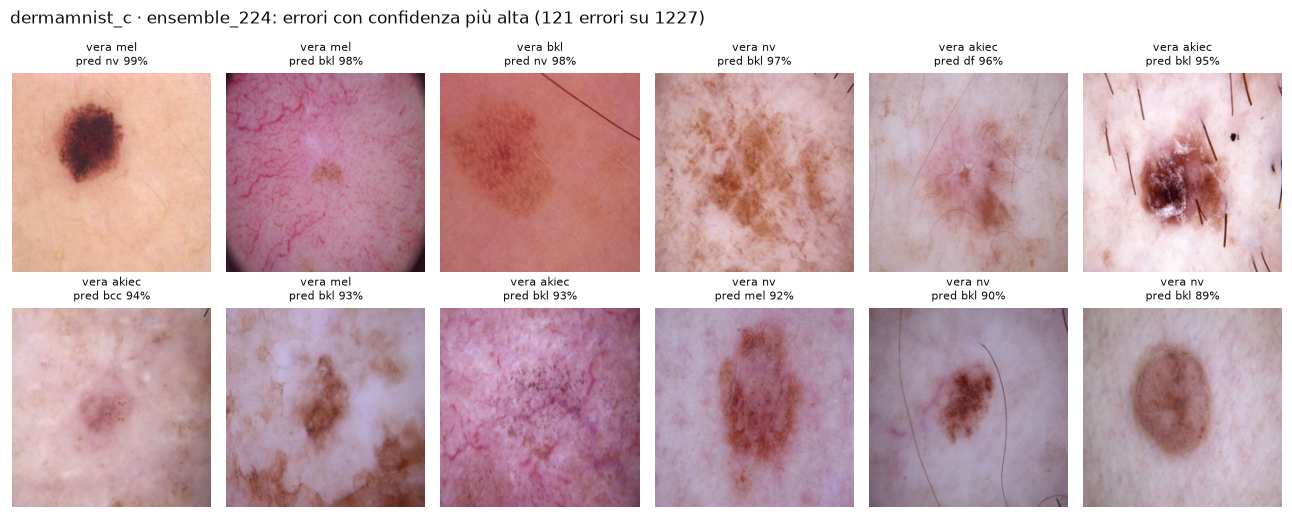

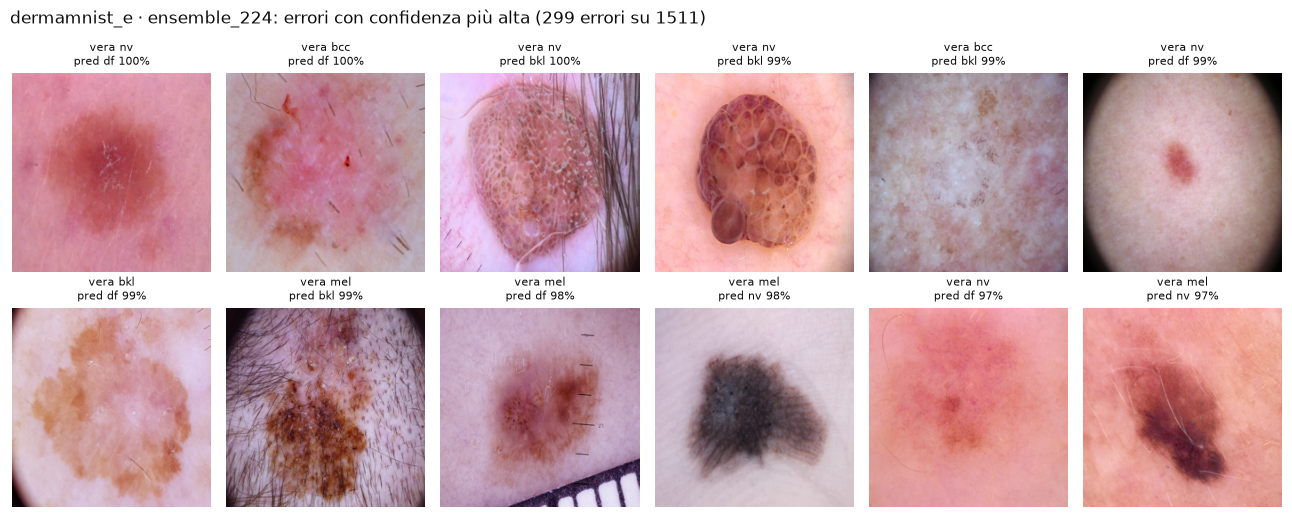

In [9]:
SHOW_MODEL = "ensemble_224" if "ensemble_224" in names else names[0]
N_SHOW = 12

for ds in PROBS:
    img_size = 224
    raw = load_split("test", None, ds, img_size, DATA_ROOT)        # immagini originali, non normalizzate
    y, p = LABELS[ds], PROBS[ds][SHOW_MODEL]
    pred, conf = p.argmax(1), p.max(1)
    wrong = np.where(pred != y)[0]
    worst = wrong[np.argsort(-conf[wrong])][:N_SHOW]
    fig, axes = plt.subplots(2, N_SHOW // 2, figsize=(2.3 * N_SHOW // 2, 5.4))
    for ax, i in zip(axes.flat, worst):
        ax.imshow(raw.imgs[i]); ax.axis("off")
        ax.set_title(f"vera {CLASSES[y[i]]}\npred {CLASSES[pred[i]]} {conf[i]:.0%}", fontsize=8, color=INK)
    fig.suptitle(f"{ds} · {SHOW_MODEL}: errori con confidenza più alta ({len(wrong)} errori su {len(y)})",
                 x=0.01, ha="left", color=INK)
    plt.tight_layout(); plt.show()

## 8 — Salvataggio

In [ ]:
report = {
    "models": {n: {k: m["cfg"].get(k) for k in ("dataset", "img_size", "pretrained", "norm", "seed")}
               for n, m in models.items()},
    "test_sets": {ds: {"images": int(len(y)), "per_class": np.bincount(y, minlength=7).tolist()}
                  for ds, y in LABELS.items()},
    "metrics": summary.to_dict(orient="records"),
    "confusion_matrices": {f"{ds}|{n}": cm.tolist() for (ds, n), cm in CONF.items()},
    "class_order": CLASSES,
}
(OUT_DIR / "test_report.json").write_text(json.dumps(report, indent=2, default=float))
for ds in PROBS:
    df = pd.DataFrame({"index": np.arange(len(LABELS[ds])), "true": [CLASSES[c] for c in LABELS[ds]]})
    for n, p in PROBS[ds].items():
        df[f"pred_{n}"] = [CLASSES[c] for c in p.argmax(1)]
        df[f"conf_{n}"] = p.max(1).round(4)
    df.to_csv(OUT_DIR / f"predictions_{ds}.csv", index=False)
print("salvato in", OUT_DIR)
for f in sorted(OUT_DIR.iterdir()): print("  ", f.name)